
# RUGD → ORFD Fine-tuning Qualitative Comparison

This notebook produces the same qualitative layout used for the RUGD → RELLIS-3D fine-tuning section:

**Input | Ground Truth | Cross-dataset | Fine-tuned**

Representative rows:
1. **Strong recovery** — DeepLabV3+
2. **Traversable/non-traversable recovery** — U-Net
3. **Residual challenge / negative-transfer case** — ROD

It does **not retrain** any model. It loads the existing Exp2 (RUGD-trained) and Exp3 (ORFD fine-tuned) checkpoints and runs inference on the same ORFD test images.


In [7]:

# 1. Mount Drive and dependencies

from google.colab import drive
drive.mount("/content/drive")

!pip -q install segmentation-models-pytorch einops opencv-python-headless pandas matplotlib tqdm

import os
import sys
import shutil
import zipfile
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [8]:
# ============================================================
# 2. Checkpoints and ORFD paths
# ============================================================

from pathlib import Path

EXP2_CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),

    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),

    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),

    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}


EXP3_CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/u_net/"
        "best_orfd_finetuned.pth"
    ),

    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/deeplabv3plus/"
        "best_orfd_finetuned.pth"
    ),

    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/segformer_b0/"
        "best_orfd_finetuned.pth"
    ),

    "ROD": Path(
        "/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/rod/"
        "best_orfd_finetuned.pth"
    ),
}


# ------------------------------------------------------------
# Raw ORFD dataset
# ------------------------------------------------------------

ORFD_RAW_ROOT = Path(
    "/content/drive/MyDrive/IRP/01_data/raw/ORFD"
)

TRAINING_ZIP = ORFD_RAW_ROOT / "training.zip"
VALIDATION_ZIP = ORFD_RAW_ROOT / "validation.zip"
TESTING_ZIP = ORFD_RAW_ROOT / "testing.zip"


# Only testing.zip is needed for this qualitative comparison
WORK_ROOT = Path(
    "/content/orfd_finetune_qualitative"
)

TEST_EXTRACT_ROOT = (
    WORK_ROOT / "testing"
)

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/IRP/"
    "04_target_domain_finetuning/orfd/"
    "qualitative_comparison"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


NON_TRAVERSABLE = 0
TRAVERSABLE = 1
IGNORE_INDEX = 255

NUM_CLASSES = 2
INPUT_SIZE = (512, 512)


print("ORFD root:", ORFD_RAW_ROOT)
print("Testing ZIP:", TESTING_ZIP)


# ------------------------------------------------------------
# Validate files
# ------------------------------------------------------------

if not TESTING_ZIP.exists():
    raise FileNotFoundError(
        f"testing.zip not found: {TESTING_ZIP}"
    )


for stage_name, checkpoints in [
    ("Exp2", EXP2_CHECKPOINTS),
    ("Exp3", EXP3_CHECKPOINTS),
]:

    print(f"\n{stage_name} checkpoints")

    for model_name, checkpoint_path in (
        checkpoints.items()
    ):

        exists = checkpoint_path.exists()

        print(
            f"{model_name:<14} "
            f"{'✓' if exists else '✗'} "
            f"{checkpoint_path}"
        )

        if not exists:
            raise FileNotFoundError(
                checkpoint_path
            )

ORFD root: /content/drive/MyDrive/IRP/01_data/raw/ORFD
Testing ZIP: /content/drive/MyDrive/IRP/01_data/raw/ORFD/testing.zip

Exp2 checkpoints
U-Net          ✓ /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+     ✓ /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
SegFormer-B0   ✓ /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
ROD            ✓ /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth

Exp3 checkpoints
U-Net          ✓ /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/u_net/best_orfd_finetuned.pth
DeepLabV3+     ✓ /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/deeplabv3plus/best_orfd_finetuned.pth
SegFormer-B0   ✓ /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/segformer_b0/best_orfd_finetuned.pth
ROD   

In [9]:
# ============================================================
# 3. Extract ORFD testing split
# ============================================================

import zipfile
import shutil


# Re-extract only if the directory is empty
if (
    not TEST_EXTRACT_ROOT.exists()
    or not any(TEST_EXTRACT_ROOT.iterdir())
):

    if TEST_EXTRACT_ROOT.exists():
        shutil.rmtree(
            TEST_EXTRACT_ROOT
        )

    TEST_EXTRACT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "Extracting ORFD testing split..."
    )

    with zipfile.ZipFile(
        TESTING_ZIP,
        "r",
    ) as zf:

        zf.extractall(
            TEST_EXTRACT_ROOT
        )

else:

    print(
        "Testing split already extracted."
    )


print(
    "Extracted to:",
    TEST_EXTRACT_ROOT,
)


# Show top-level structure
print("\nTop-level contents:")

for p in sorted(
    TEST_EXTRACT_ROOT.iterdir()
):
    print(" ", p)

Extracting ORFD testing split...
Extracted to: /content/orfd_finetune_qualitative/testing

Top-level contents:
  /content/orfd_finetune_qualitative/testing/testing


In [12]:
# ============================================================
# 4. Build ORFD testing image / GT pairs sequence by sequence
# ============================================================

from pathlib import Path
import pandas as pd
import os


IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
}


def list_image_files(folder):
    """
    Recursively return all image files in a folder.
    """
    return sorted(
        [
            p
            for p in Path(folder).rglob("*")
            if (
                p.is_file()
                and p.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]
    )


# ------------------------------------------------------------
# Locate the actual testing root
#
# Current extraction looks like:
# /content/orfd_finetune_qualitative/testing/testing/...
# ------------------------------------------------------------

possible_testing_roots = [
    TEST_EXTRACT_ROOT / "testing",
    TEST_EXTRACT_ROOT,
]

TESTING_ROOT = None

for candidate in possible_testing_roots:

    if not candidate.exists():
        continue

    sequence_dirs = [
        p
        for p in candidate.iterdir()
        if (
            p.is_dir()
            and (p / "image_data").exists()
            and (p / "gt_image").exists()
        )
    ]

    if sequence_dirs:
        TESTING_ROOT = candidate
        break


if TESTING_ROOT is None:

    raise RuntimeError(
        "Could not locate ORFD testing sequence folders "
        "containing both image_data and gt_image."
    )


print(
    "Detected ORFD testing root:",
    TESTING_ROOT
)


# ------------------------------------------------------------
# Find all sequence directories
# ------------------------------------------------------------

sequence_dirs = sorted(
    [
        p
        for p in TESTING_ROOT.iterdir()
        if (
            p.is_dir()
            and (p / "image_data").exists()
            and (p / "gt_image").exists()
        )
    ]
)


print(
    f"\nFound {len(sequence_dirs)} testing sequences:"
)

for seq in sequence_dirs:
    print(" ", seq.name)


# ------------------------------------------------------------
# Pair RGB and GT within each sequence
# ------------------------------------------------------------

rows = []


for seq_dir in sequence_dirs:

    image_dir = (
        seq_dir / "image_data"
    )

    gt_dir = (
        seq_dir / "gt_image"
    )


    image_files = list_image_files(
        image_dir
    )

    gt_files = list_image_files(
        gt_dir
    )


    print(
        f"\nSequence: {seq_dir.name}"
    )

    print(
        f"  RGB images: {len(image_files)}"
    )

    print(
        f"  GT masks:   {len(gt_files)}"
    )


    if len(image_files) == 0:

        raise RuntimeError(
            f"No RGB images found in "
            f"{image_dir}"
        )


    if len(gt_files) == 0:

        raise RuntimeError(
            f"No GT images found in "
            f"{gt_dir}"
        )


    # --------------------------------------------------------
    # IMPORTANT
    #
    # ORFD image_data and gt_image filenames do not
    # necessarily have identical stems.
    #
    # They are stored in corresponding temporal order,
    # so pair them after sorting.
    # --------------------------------------------------------

    if len(image_files) != len(gt_files):

        print(
            "  WARNING: number of RGB images "
            "and GT masks differs."
        )

        print(
            "  Pairing only the common number "
            "of frames."
        )


    n_pairs = min(
        len(image_files),
        len(gt_files),
    )


    for i in range(n_pairs):

        rows.append(
            {
                "sequence":
                    seq_dir.name,

                "frame_index":
                    i,

                "image_path":
                    str(
                        image_files[i]
                    ),

                "mask_path":
                    str(
                        gt_files[i]
                    ),
            }
        )


# ------------------------------------------------------------
# Create final ORFD test dataframe
# ------------------------------------------------------------

test_df = pd.DataFrame(
    rows
)


if len(test_df) == 0:

    raise RuntimeError(
        "No ORFD testing pairs were created."
    )


print(
    "\n========================================"
)

print(
    "Total ORFD test pairs:",
    len(test_df)
)

print(
    "========================================"
)


display(
    test_df.head(10)
)

Detected ORFD testing root: /content/orfd_finetune_qualitative/testing/testing

Found 6 testing sequences:
  x2021_0223_1756
  y0602_1330
  y0609_1923
  y0613_1220
  y0613_1242
  y2021_0228_1802

Sequence: x2021_0223_1756
  RGB images: 359
  GT masks:   359

Sequence: y0602_1330
  RGB images: 362
  GT masks:   362

Sequence: y0609_1923
  RGB images: 405
  GT masks:   405

Sequence: y0613_1220
  RGB images: 300
  GT masks:   300

Sequence: y0613_1242
  RGB images: 409
  GT masks:   409

Sequence: y2021_0228_1802
  RGB images: 720
  GT masks:   720

Total ORFD test pairs: 2555


,sequence,frame_index,image_path,mask_path
0,x2021_0223_1756,0,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
1,x2021_0223_1756,1,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
2,x2021_0223_1756,2,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
3,x2021_0223_1756,3,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
4,x2021_0223_1756,4,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
5,x2021_0223_1756,5,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
6,x2021_0223_1756,6,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
7,x2021_0223_1756,7,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
8,x2021_0223_1756,8,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...
9,x2021_0223_1756,9,/content/orfd_finetune_qualitative/testing/tes...,/content/orfd_finetune_qualitative/testing/tes...


In [13]:
print(test_df.iloc[0])

print("\nRGB:")
print(test_df.iloc[0]["image_path"])

print("\nGT:")
print(test_df.iloc[0]["mask_path"])

sequence                                         x2021_0223_1756
frame_index                                                    0
image_path     /content/orfd_finetune_qualitative/testing/tes...
mask_path      /content/orfd_finetune_qualitative/testing/tes...
Name: 0, dtype: object

RGB:
/content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/image_data/1620322699201.png

GT:
/content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/gt_image/1620322699201_fillcolor.png


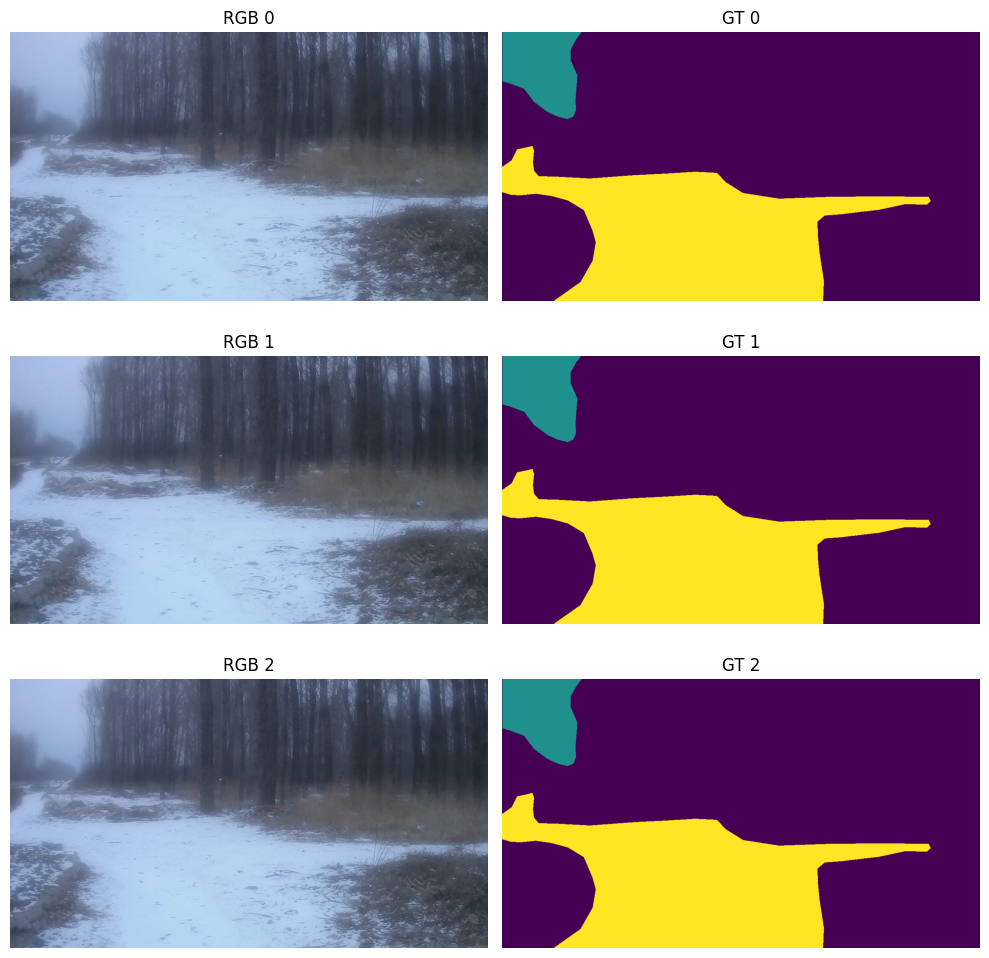

In [14]:
# ============================================================
# Sanity check: RGB / GT pairing
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


fig, axes = plt.subplots(
    3,
    2,
    figsize=(10, 10),
)


for i in range(3):

    row = test_df.iloc[i]

    image = np.array(
        Image.open(
            row["image_path"]
        ).convert("RGB")
    )

    gt = np.array(
        Image.open(
            row["mask_path"]
        )
    )


    axes[i, 0].imshow(
        image
    )

    axes[i, 0].set_title(
        f"RGB {i}"
    )


    axes[i, 1].imshow(
        gt
    )

    axes[i, 1].set_title(
        f"GT {i}"
    )


    for j in range(2):

        axes[i, j].axis(
            "off"
        )


plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Inspect ORFD GT format
# ============================================================

for i in range(
    min(
        5,
        len(test_df),
    )
):

    mask_path = (
        test_df.iloc[i][
            "mask_path"
        ]
    )

    mask = np.array(
        Image.open(
            mask_path
        )
    )

    print(
        f"\nSample {i}"
    )

    print(
        "Path:",
        mask_path
    )

    print(
        "Shape:",
        mask.shape
    )

    if mask.ndim == 2:

        print(
            "Unique values:",
            np.unique(mask)
        )

    elif mask.ndim == 3:

        unique_colors = np.unique(
            mask.reshape(
                -1,
                mask.shape[-1]
            ),
            axis=0,
        )

        print(
            "Unique colours:",
            unique_colors[:20]
        )

        print(
            "Number of colours:",
            len(unique_colors)
        )


Sample 0
Path: /content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/gt_image/1620322699201_fillcolor.png
Shape: (720, 1280)
Unique values: [  0 128 255]

Sample 1
Path: /content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/gt_image/1620322699293_fillcolor.png
Shape: (720, 1280)
Unique values: [  0 128 255]

Sample 2
Path: /content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/gt_image/1620322699481_fillcolor.png
Shape: (720, 1280)
Unique values: [  0 128 255]

Sample 3
Path: /content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/gt_image/1620322699599_fillcolor.png
Shape: (720, 1280)
Unique values: [  0 128 255]

Sample 4
Path: /content/orfd_finetune_qualitative/testing/testing/x2021_0223_1756/gt_image/1620322699679_fillcolor.png
Shape: (720, 1280)
Unique values: [  0 128 255]


In [16]:
def read_binary_mask(path):
    """
    Convert raw ORFD mask values to the binary evaluation format:

        raw 0   -> 0   : non-traversable
        raw 128 -> 255 : ignore / unreachable
        raw 255 -> 1   : traversable
    """

    raw = np.array(
        Image.open(path)
    )

    if raw.ndim == 3:
        # ORFD gt_image should normally be single-channel.
        # If loaded as repeated RGB channels, reduce it safely.
        if (
            np.array_equal(raw[..., 0], raw[..., 1])
            and np.array_equal(raw[..., 0], raw[..., 2])
        ):
            raw = raw[..., 0]
        else:
            raise ValueError(
                f"Unexpected RGB mask format: {path}"
            )

    raw = raw.astype(np.uint8)

    unique_values = set(
        np.unique(raw).tolist()
    )

    expected_values = {
        0,
        128,
        255,
    }

    if not unique_values.issubset(
        expected_values
    ):
        raise ValueError(
            f"Unexpected ORFD mask values "
            f"{sorted(unique_values)} in {path}"
        )

    # Start everything as IGNORE
    mask = np.full(
        raw.shape,
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    # raw 0 -> non-traversable
    mask[raw == 0] = NON_TRAVERSABLE

    # raw 255 -> traversable
    mask[raw == 255] = TRAVERSABLE

    # raw 128 remains IGNORE_INDEX = 255
    mask[raw == 128] = IGNORE_INDEX

    return mask

In [19]:
for i in range(5):

    mask_path = test_df.iloc[i]["mask_path"]

    mapped_mask = read_binary_mask(
        mask_path
    )

    print(
        f"Sample {i}:",
        np.unique(mapped_mask)
    )

Sample 0: [  0   1 255]
Sample 1: [  0   1 255]
Sample 2: [  0   1 255]
Sample 3: [  0   1 255]
Sample 4: [  0   1 255]


In [20]:

# 5. Preprocessing and datasets

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

PIXEL_MEAN_255 = np.array([123.675, 116.28, 103.53], dtype=np.float32)
PIXEL_STD_255  = np.array([58.395, 57.12, 57.375], dtype=np.float32)

def resize_pad(image, mask, size=512):
    h, w = image.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(round(h * scale)), int(round(w * scale))

    im = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    ma = cv2.resize(mask, (nw, nh), interpolation=cv2.INTER_NEAREST)

    top = (size - nh) // 2
    bottom = size - nh - top
    left = (size - nw) // 2
    right = size - nw - left

    im = cv2.copyMakeBorder(im, top, bottom, left, right,
                            cv2.BORDER_CONSTANT, value=(0, 0, 0))
    ma = cv2.copyMakeBorder(ma, top, bottom, left, right,
                            cv2.BORDER_CONSTANT, value=IGNORE_INDEX)
    return im, ma

class ORFDInferenceDataset(Dataset):
    def __init__(self, dataframe, mode):
        self.df = dataframe.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row["image_path"]).convert("RGB"))
        mask = read_binary_mask(row["mask_path"])

        if self.mode == "direct_resize":
            image_p = cv2.resize(image, INPUT_SIZE[::-1], interpolation=cv2.INTER_LINEAR)
            mask_p = cv2.resize(mask, INPUT_SIZE[::-1], interpolation=cv2.INTER_NEAREST)

            x = image_p.astype(np.float32) / 255.0
            x = (x - IMAGENET_MEAN) / IMAGENET_STD

        elif self.mode == "aspect_ratio_pad":
            image_p, mask_p = resize_pad(image, mask, INPUT_SIZE[0])
            x = (image_p.astype(np.float32) - PIXEL_MEAN_255) / PIXEL_STD_255

        else:
            raise ValueError(self.mode)

        return {
            "image": torch.from_numpy(x).permute(2, 0, 1).contiguous(),
            "mask": torch.from_numpy(mask_p.astype(np.int64)),
            "index": torch.tensor(idx, dtype=torch.long),
        }

baseline_loader = DataLoader(
    ORFDInferenceDataset(test_df, "direct_resize"),
    batch_size=8, shuffle=False, num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)

rod_loader = DataLoader(
    ORFDInferenceDataset(test_df, "aspect_ratio_pad"),
    batch_size=1, shuffle=False, num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
)


In [21]:

# 6. U-Net / DeepLabV3+ / SegFormer-B0 definitions

def build_baseline_model(name):
    if name == "U-Net":
        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
        )
    elif name == "DeepLabV3+":
        model = smp.DeepLabV3Plus(
            encoder_name="resnet34",
            encoder_weights=None,
            encoder_output_stride=16,
            in_channels=3,
            classes=NUM_CLASSES,
        )
    elif name == "SegFormer-B0":
        model = smp.Segformer(
            encoder_name="mit_b0",
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
        )
    else:
        raise ValueError(name)
    return model.to(DEVICE)

def extract_state_dict(obj):
    if isinstance(obj, dict):
        for key in ["model_state_dict", "state_dict", "model", "net"]:
            if key in obj and isinstance(obj[key], dict):
                return obj[key]
    return obj

def normalize_state_dict_keys(state):
    state = dict(state)
    for prefix in ["module.", "model."]:
        if state and all(k.startswith(prefix) for k in state):
            state = {k[len(prefix):]: v for k, v in state.items()}
    return state

def load_checkpoint_strict(model, path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    state = normalize_state_dict_keys(extract_state_dict(ckpt))
    try:
        model.load_state_dict(state, strict=True)
    except RuntimeError as e:
        print("Checkpoint:", path)
        print("Checkpoint key examples:", list(state)[:8])
        print("Model key examples:", list(model.state_dict())[:8])
        raise RuntimeError(
            "Checkpoint/model architecture mismatch. "
            "Do not switch to strict=False for the dissertation results."
        ) from e
    model.eval()
    return model

# Smoke test all baseline checkpoints, Exp2 and Exp3.
for stage, cps in [("Exp2", EXP2_CHECKPOINTS), ("Exp3", EXP3_CHECKPOINTS)]:
    for name in ["U-Net", "DeepLabV3+", "SegFormer-B0"]:
        print(stage, name)
        m = load_checkpoint_strict(build_baseline_model(name), cps[name])
        del m
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

print("Baseline checkpoint smoke tests passed.")


Exp2 U-Net
Exp2 DeepLabV3+
Exp2 SegFormer-B0
Exp3 U-Net
Exp3 DeepLabV3+
Exp3 SegFormer-B0
Baseline checkpoint smoke tests passed.


In [22]:

# 7. ROD definition

ROD_REPO = Path("/content/offroad_roadseg")

def run_cmd(cmd):
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)

if not ROD_REPO.exists():
    run_cmd(
        "git clone --depth 1 "
        "https://github.com/ict-ans-617/offroad_roadseg.git "
        f"{ROD_REPO}"
    )

sys.path.insert(0, str(ROD_REPO))

WEIGHTS_DIR = ROD_REPO / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"
VITS_ZIP = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"

if not VITS_PATH.exists():
    if not VITS_ZIP.exists():
        run_cmd(
            "wget -q --show-progress "
            "https://github.com/yformer/EfficientSAM/raw/main/"
            "weights/efficient_sam_vits.pt.zip "
            f"-O {VITS_ZIP}"
        )
    with zipfile.ZipFile(VITS_ZIP, "r") as zf:
        zf.extractall(WEIGHTS_DIR)

from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead

def load_rod_encoder(checkpoint_path):
    expected = (ROD_REPO / "efficient_sam" / "weights" / "efficient_sam_vits.pt").resolve()
    source = Path(checkpoint_path).resolve()
    if source != expected:
        shutil.copy2(source, expected)

    cwd = Path.cwd()
    try:
        os.chdir(ROD_REPO / "efficient_sam")
        model = build_efficient_sam_vits()
    finally:
        os.chdir(cwd)
    return model.image_encoder

class ROD(nn.Module):
    def __init__(self, encoder_checkpoint, freeze=True):
        super().__init__()
        self.encoder = load_rod_encoder(encoder_checkpoint)
        self.decoder = SegHead()
        self.freeze = freeze
        self.encoder_input_size = int(self.encoder.img_size)

        if freeze:
            for p in self.encoder.parameters():
                p.requires_grad = False
            self.encoder.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze:
            self.encoder.eval()
        return self

    def forward(self, x):
        out_size = x.shape[-2:]

        if x.shape[-2:] != (self.encoder_input_size, self.encoder_input_size):
            enc_x = F.interpolate(
                x,
                size=(self.encoder_input_size, self.encoder_input_size),
                mode="bilinear",
                align_corners=False,
            )
        else:
            enc_x = x

        if self.freeze:
            with torch.no_grad():
                feats = self.encoder(enc_x)
        else:
            feats = self.encoder(enc_x)

        logits = self.decoder(feats)

        if logits.shape[-2:] != out_size:
            logits = F.interpolate(
                logits, size=out_size,
                mode="bilinear", align_corners=False
            )
        return logits

def build_rod_model():
    return ROD(VITS_PATH, freeze=True).to(DEVICE)

for stage, cps in [("Exp2", EXP2_CHECKPOINTS), ("Exp3", EXP3_CHECKPOINTS)]:
    print(stage, "ROD")
    m = load_checkpoint_strict(build_rod_model(), cps["ROD"])
    del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("ROD checkpoint smoke tests passed.")


git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git /content/offroad_roadseg
wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O /content/offroad_roadseg/efficient_sam/weights/efficient_sam_vits.pt.zip
Exp2 ROD
Exp3 ROD
ROD checkpoint smoke tests passed.


In [23]:

# 8. Per-image evaluation

def per_image_metrics(pred, target):
    valid = target != IGNORE_INDEX
    ious = []

    for cls in [NON_TRAVERSABLE, TRAVERSABLE]:
        p = (pred == cls) & valid
        t = (target == cls) & valid
        inter = np.logical_and(p, t).sum()
        union = np.logical_or(p, t).sum()
        ious.append(inter / union if union > 0 else np.nan)

    return {
        "non_traversable_iou": ious[0],
        "traversable_iou": ious[1],
        "miou": float(np.nanmean(ious)),
    }

@torch.inference_mode()
def evaluate_checkpoint_per_image(model_name, checkpoint):
    if model_name == "ROD":
        model = build_rod_model()
        loader = rod_loader
    else:
        model = build_baseline_model(model_name)
        loader = baseline_loader

    model = load_checkpoint_strict(model, checkpoint)
    rows = []

    for batch in tqdm(loader, desc=f"{model_name} | {checkpoint.name}"):
        images = batch["image"].to(DEVICE, non_blocking=True)
        targets = batch["mask"].cpu().numpy()
        indices = batch["index"].cpu().numpy()

        logits = model(images)
        if isinstance(logits, dict):
            logits = logits["out"]
        elif hasattr(logits, "logits"):
            logits = logits.logits

        if logits.shape[-2:] != images.shape[-2:]:
            logits = F.interpolate(
                logits, size=images.shape[-2:],
                mode="bilinear", align_corners=False
            )

        preds = logits.argmax(1).cpu().numpy()

        for i, idx in enumerate(indices):
            rows.append({
                "index": int(idx),
                **per_image_metrics(preds[i], targets[i])
            })

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return pd.DataFrame(rows).sort_values("index").reset_index(drop=True)


In [24]:

# 9. Build Exp2-vs-Exp3 per-image comparison
#
# Only 3 models are needed for the final figure. Results are cached.

CASE_MODELS = ["DeepLabV3+", "U-Net", "ROD"]
comparison_dfs = {}

for model_name in CASE_MODELS:
    safe = model_name.lower().replace("+", "plus").replace("-", "_")
    cache = OUTPUT_ROOT / f"{safe}_exp2_exp3_per_image.csv"

    if cache.exists():
        print("Loading cache:", cache)
        comparison_dfs[model_name] = pd.read_csv(cache)
        continue

    e2 = evaluate_checkpoint_per_image(
        model_name, EXP2_CHECKPOINTS[model_name]
    ).rename(columns={
        "non_traversable_iou": "exp2_non_traversable_iou",
        "traversable_iou": "exp2_traversable_iou",
        "miou": "exp2_miou",
    })

    e3 = evaluate_checkpoint_per_image(
        model_name, EXP3_CHECKPOINTS[model_name]
    ).rename(columns={
        "non_traversable_iou": "exp3_non_traversable_iou",
        "traversable_iou": "exp3_traversable_iou",
        "miou": "exp3_miou",
    })

    df = e2.merge(e3, on="index", how="inner")
    df["delta_miou"] = df["exp3_miou"] - df["exp2_miou"]
    df["delta_non_traversable_iou"] = (
        df["exp3_non_traversable_iou"] - df["exp2_non_traversable_iou"]
    )
    df["delta_traversable_iou"] = (
        df["exp3_traversable_iou"] - df["exp2_traversable_iou"]
    )

    df.to_csv(cache, index=False)
    comparison_dfs[model_name] = df
    print("Saved:", cache)


DeepLabV3+ | deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth:   0%|          | 0/320 [00:00<?, ?it…

DeepLabV3+ | best_orfd_finetuned.pth:   0%|          | 0/320 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/qualitative_comparison/deeplabv3plus_exp2_exp3_per_image.csv


U-Net | unet_resnet34_rugd_binary_ground_best_20epochs.pth:   0%|          | 0/320 [00:00<?, ?it/s]

U-Net | best_orfd_finetuned.pth:   0%|          | 0/320 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/qualitative_comparison/u_net_exp2_exp3_per_image.csv


ROD | rod_rugd_binary_ground_best_20epochs.pth:   0%|          | 0/2555 [00:00<?, ?it/s]

ROD | best_orfd_finetuned.pth:   0%|          | 0/2555 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/qualitative_comparison/rod_exp2_exp3_per_image.csv


In [25]:

# 10. Representative case selection
#
# Strong recovery: DeepLabV3+, largest mIoU gain
# Non-traversable recovery: U-Net, largest non-traversable IoU gain
# Residual challenge: ROD, largest negative/weakest improvement after fine-tuning

selected_cases = {}

row = (
    comparison_dfs["DeepLabV3+"]
    .dropna(subset=["delta_miou"])
    .sort_values("delta_miou", ascending=False)
    .iloc[0]
)
selected_cases["Strong recovery"] = {
    "model": "DeepLabV3+",
    "index": int(row["index"]),
}

cand = comparison_dfs["U-Net"].dropna(
    subset=["delta_non_traversable_iou", "exp3_miou"]
)
# Avoid selecting a bizarre almost-empty case.
good = cand[cand["exp3_miou"] >= 0.70]
if len(good):
    cand = good

row = cand.sort_values(
    "delta_non_traversable_iou", ascending=False
).iloc[0]
selected_cases["Non-traversable recovery"] = {
    "model": "U-Net",
    "index": int(row["index"]),
}

rod_df = comparison_dfs["ROD"].dropna(subset=["delta_miou", "exp3_miou"])

# Prefer a genuine negative-transfer example if one exists.
negative = rod_df[rod_df["delta_miou"] < -0.05]
if len(negative):
    row = negative.sort_values("delta_miou", ascending=True).iloc[0]
else:
    # Otherwise select the lowest post-finetuning mIoU, excluding pathological values.
    reasonable = rod_df[rod_df["exp3_miou"] >= 0.20]
    if len(reasonable):
        rod_df = reasonable
    row = rod_df.sort_values("exp3_miou", ascending=True).iloc[0]

selected_cases["Residual challenge"] = {
    "model": "ROD",
    "index": int(row["index"]),
}

for case, info in selected_cases.items():
    df = comparison_dfs[info["model"]]
    r = df[df["index"] == info["index"]].iloc[0]
    print(
        f"{case:<26} | {info['model']:<12} | idx={info['index']:4d} | "
        f"mIoU {r['exp2_miou']:.3f} -> {r['exp3_miou']:.3f} "
        f"({r['delta_miou']:+.3f})"
    )


Strong recovery            | DeepLabV3+   | idx=2206 | mIoU 0.245 -> 0.967 (+0.722)
Non-traversable recovery   | U-Net        | idx=2041 | mIoU 0.139 -> 0.981 (+0.842)
Residual challenge         | ROD          | idx=1988 | mIoU 0.196 -> 0.639 (+0.443)


In [26]:

# 11. Single-image prediction and visualization utilities

def preprocess_single(image, mask, model_name):
    if model_name == "ROD":
        image_p, mask_p = resize_pad(image, mask, INPUT_SIZE[0])
        x = (image_p.astype(np.float32) - PIXEL_MEAN_255) / PIXEL_STD_255
    else:
        image_p = cv2.resize(image, INPUT_SIZE[::-1], interpolation=cv2.INTER_LINEAR)
        mask_p = cv2.resize(mask, INPUT_SIZE[::-1], interpolation=cv2.INTER_NEAREST)
        x = image_p.astype(np.float32) / 255.0
        x = (x - IMAGENET_MEAN) / IMAGENET_STD

    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).float()
    return x, mask_p

@torch.inference_mode()
def predict_selected(model_name, checkpoint, index):
    row = test_df.iloc[index]
    raw_image = np.array(Image.open(row["image_path"]).convert("RGB"))
    raw_mask = read_binary_mask(row["mask_path"])

    x, eval_mask = preprocess_single(raw_image, raw_mask, model_name)

    model = (
        build_rod_model()
        if model_name == "ROD"
        else build_baseline_model(model_name)
    )
    model = load_checkpoint_strict(model, checkpoint)

    logits = model(x.to(DEVICE))
    if isinstance(logits, dict):
        logits = logits["out"]
    elif hasattr(logits, "logits"):
        logits = logits.logits

    if logits.shape[-2:] != eval_mask.shape:
        logits = F.interpolate(
            logits, size=eval_mask.shape,
            mode="bilinear", align_corners=False
        )

    pred = logits.argmax(1)[0].cpu().numpy().astype(np.uint8)
    metrics = per_image_metrics(pred, eval_mask)

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "raw_image": raw_image,
        "eval_mask": eval_mask,
        "prediction": pred,
        **metrics,
    }

def error_map(pred, target):
    out = np.zeros((*target.shape, 3), dtype=np.uint8)
    valid = target != IGNORE_INDEX

    # ORFD terminology
    out[(target == NON_TRAVERSABLE) & (pred == NON_TRAVERSABLE) & valid] = [0, 0, 0]
    out[(target == TRAVERSABLE) & (pred == TRAVERSABLE) & valid] = [255, 255, 255]
    out[(target == NON_TRAVERSABLE) & (pred == TRAVERSABLE) & valid] = [255, 0, 0]
    out[(target == TRAVERSABLE) & (pred == NON_TRAVERSABLE) & valid] = [0, 0, 255]
    out[target == IGNORE_INDEX] = [140, 140, 140]
    return out

def gt_rgb(target):
    out = np.zeros((*target.shape, 3), dtype=np.uint8)
    out[target == NON_TRAVERSABLE] = [0, 0, 0]
    out[target == TRAVERSABLE] = [255, 255, 255]
    out[target == IGNORE_INDEX] = [140, 140, 140]
    return out

def restore_from_padding(arr, padded_mask, original_shape):
    valid = padded_mask != IGNORE_INDEX
    ys, xs = np.where(valid)
    if len(xs) == 0:
        raise ValueError("No valid pixels in padded mask.")

    crop = arr[ys.min():ys.max()+1, xs.min():xs.max()+1]
    h, w = original_shape
    return cv2.resize(crop, (w, h), interpolation=cv2.INTER_NEAREST)


Rendering Strong recovery: DeepLabV3+, index=2206
Rendering Non-traversable recovery: U-Net, index=2041
Rendering Residual challenge: ROD, index=1988


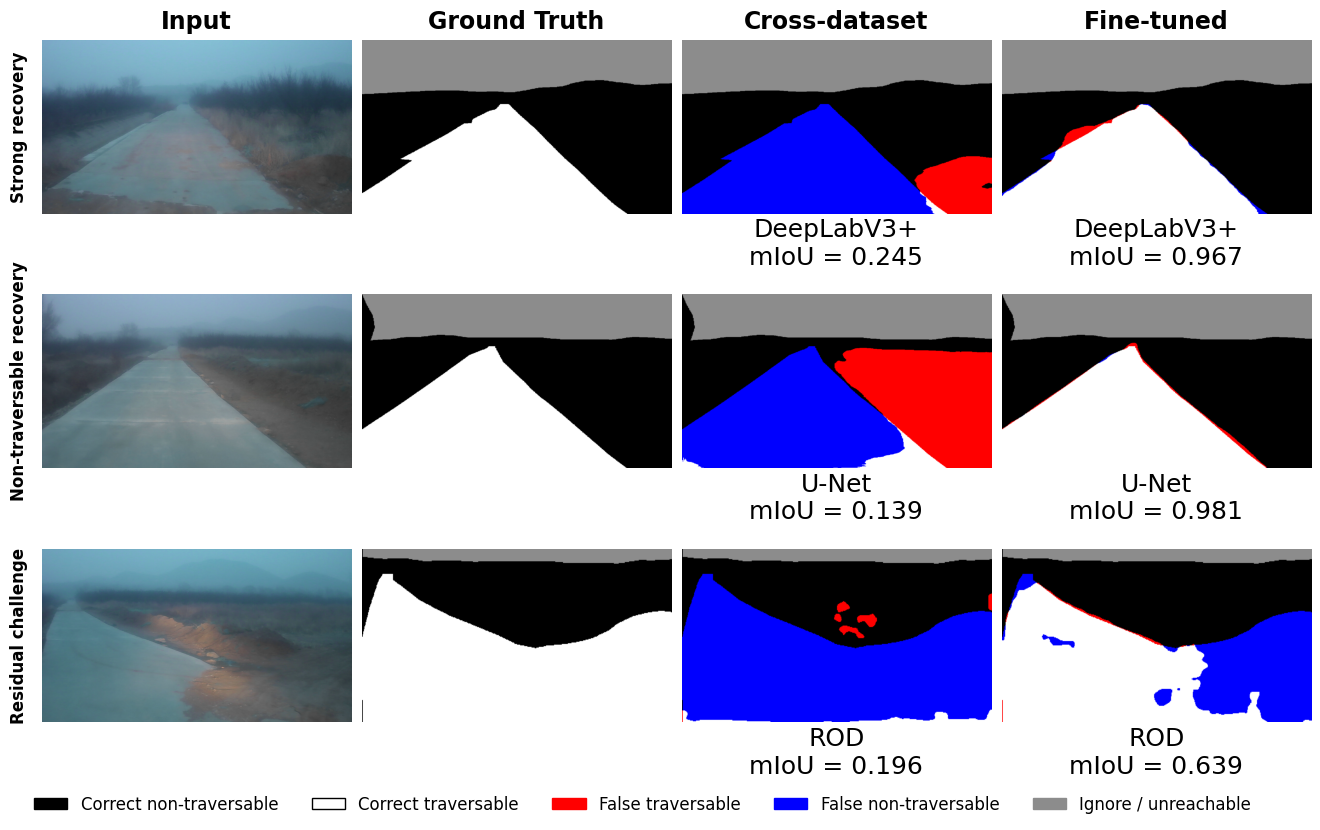

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/qualitative_comparison/rugd_to_orfd_finetuning_qualitative.png


In [29]:

# 12. Final dissertation-style figure

figure_rows = {}

for case, info in selected_cases.items():
    model_name = info["model"]
    idx = info["index"]

    print(f"Rendering {case}: {model_name}, index={idx}")

    exp2 = predict_selected(
        model_name, EXP2_CHECKPOINTS[model_name], idx
    )
    exp3 = predict_selected(
        model_name, EXP3_CHECKPOINTS[model_name], idx
    )

    figure_rows[case] = {
        "model": model_name,
        "exp2": exp2,
        "exp3": exp3,
    }

fig, axes = plt.subplots(3, 4, figsize=(13.5, 8.6))

titles = ["Input", "Ground Truth", "Cross-dataset", "Fine-tuned"]
for c, title in enumerate(titles):
    axes[0, c].set_title(title, fontsize=17, fontweight="bold", pad=8)

for r, (case, info) in enumerate(figure_rows.items()):
    model_name = info["model"]
    e2, e3 = info["exp2"], info["exp3"]
    raw = e2["raw_image"]
    h, w = raw.shape[:2]

    if model_name == "ROD":
        gt = restore_from_padding(e2["eval_mask"], e2["eval_mask"], (h, w))
        p2 = restore_from_padding(e2["prediction"], e2["eval_mask"], (h, w))
        p3 = restore_from_padding(e3["prediction"], e3["eval_mask"], (h, w))
    else:
        gt = cv2.resize(e2["eval_mask"], (w, h), interpolation=cv2.INTER_NEAREST)
        p2 = cv2.resize(e2["prediction"], (w, h), interpolation=cv2.INTER_NEAREST)
        p3 = cv2.resize(e3["prediction"], (w, h), interpolation=cv2.INTER_NEAREST)

    axes[r, 0].imshow(raw)
    axes[r, 1].imshow(gt_rgb(gt))
    axes[r, 2].imshow(error_map(p2, gt))
    axes[r, 3].imshow(error_map(p3, gt))

    axes[r, 2].set_xlabel(
        f"{model_name}\nmIoU = {e2['miou']:.3f}",
        fontsize=18, labelpad=3
    )
    axes[r, 3].set_xlabel(
        f"{model_name}\nmIoU = {e3['miou']:.3f}",
        fontsize=18, labelpad=3
    )

    axes[r, 0].set_ylabel(
        case, fontsize=12, fontweight="bold", labelpad=10
    )

    for c in range(4):
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])
        for spine in axes[r, c].spines.values():
            spine.set_visible(False)

legend = [
    mpatches.Patch(facecolor="black", edgecolor="black",
                   label="Correct non-traversable"),
    mpatches.Patch(facecolor="white", edgecolor="black",
                   label="Correct traversable"),
    mpatches.Patch(facecolor="red", edgecolor="red",
                   label="False traversable"),
    mpatches.Patch(facecolor="blue", edgecolor="blue",
                   label="False non-traversable"),
    mpatches.Patch(facecolor="0.55", edgecolor="0.55",
                   label="Ignore / unreachable"),
]

fig.legend(
    handles=legend,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.005),
)

# Tight column spacing, same style as the corrected RELLIS figure.
plt.subplots_adjust(
    left=0.055,
    right=0.995,
    top=0.94,
    bottom=0.11,
    wspace=0.035,
    hspace=0.24,
)

FIG_PATH = OUTPUT_ROOT / "rugd_to_orfd_finetuning_qualitative.png"
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG_PATH)



### Selection logic

The figure is intentionally not a simple best-case gallery.

- **Strong recovery:** the DeepLabV3+ sample with the largest Exp2→Exp3 per-image mIoU increase.
- **Non-traversable recovery:** a U-Net example with a strong improvement in non-traversable IoU.
- **Residual challenge:** preferentially selects an ROD image where fine-tuning causes a meaningful per-image decrease; if none exists, it selects a difficult remaining fine-tuned example.

This parallels the RUGD → RELLIS-3D qualitative analysis while using ORFD terminology (`traversable`, `non-traversable`, `unreachable`).
